In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import itertools
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [2]:
def preprocess_plot(df, cat_name , name,  palette, order, plotting = False):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Sag (mV)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'RI (MΩ)', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        
        else:
            param_df = df
        
        try:
            unique_cat = df[cat_name].unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:
                should_plot = False
                # _, p = stats.ttest_ind(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                #                         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
                #                     equal_var = False)

                _, p = stats.mannwhitneyu(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                                        param_df[(param_df[cat_name] == combo[1])][column].dropna())
            
                print(column, combo, p)
               

           
        except ValueError:
            
            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())
                

                sns.set(rc={"figure.figsize": (2, 3)})
                sns.set(font_scale=2.5) 
                sns.set_style("ticks")

                ax = sns.boxplot(x=cat_name, y=column, data = param_df, order = order, palette = palette, 
                                saturation=8, linewidth=1.7, showfliers = False, boxprops=dict(alpha=0.5))
                ax = sns.stripplot(x=cat_name, y=column, data = param_df, order=order, 
                                jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = palette, alpha=0.5, zorder=0)
                ax.set_xlabel('')
                plt.xticks(rotation = 45)
                # ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-',  'Y-KD') , rotation=45)
                ax.yaxis.set_major_locator(plt.MaxNLocator(4))
                plt.ylabel(column.replace('_', ' '))

                sns.despine()
                
                plt.savefig(f'output_figures/{column}.png',
                    dpi=300,bbox_inches='tight', transparent=True)
                # plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{column}.pdf',
                #     dpi=300,bbox_inches='tight', transparent=True)
                plt.show()
            except KeyError:
                pass

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]

    print(stats.fisher_exact(prop))
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

Cm(pF) ('Pre', 'Post') 0.6021807774866788
pre_post_state
Post    40.410829
Pre     37.764747
Name: Cm(pF), dtype: float64


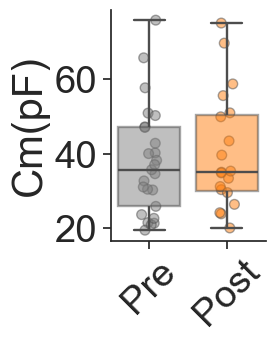

Firing_freq_(Hz)_I0 ('Pre', 'Post') 0.03002288564569688
pre_post_state
Post    0.517200
Pre     1.885635
Name: Firing_freq_(Hz)_I0, dtype: float64


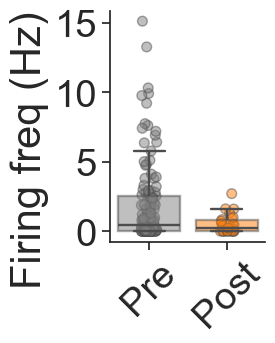

Instant_freq_(Hz) ('Pre', 'Post') 0.02010447294757824
pre_post_state
Post    0.807600
Pre     2.258413
Name: Instant_freq_(Hz), dtype: float64


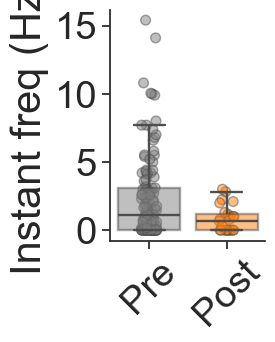

isi_(ms) ('Pre', 'Post') 0.1687094401341298
pre_post_state
Post    1866.371429
Pre     3554.709239
Name: isi_(ms), dtype: float64


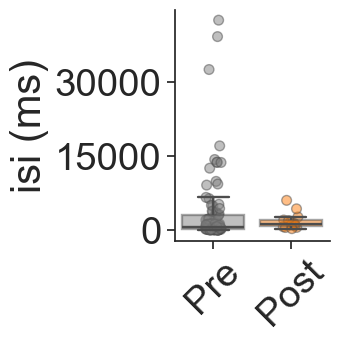

CaT ('Pre', 'Post') 0.8165407361637076
pre_post_state
Post    4.950833
Pre     5.716373
Name: CaT, dtype: float64


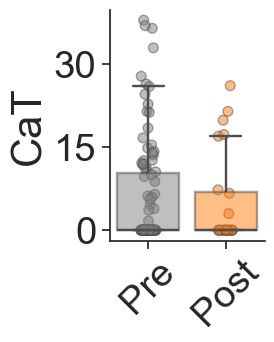

Sag (mV) ('Pre', 'Post') 0.05030278864512749
pre_post_state
Post    3.750417
Pre     6.826408
Name: Sag (mV), dtype: float64


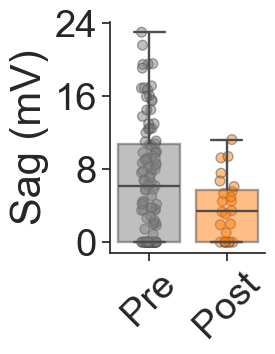

AP_ampl ('Pre', 'Post') 0.813043317323599
pre_post_state
Post    91.063571
Pre     89.257273
Name: AP_ampl, dtype: float64


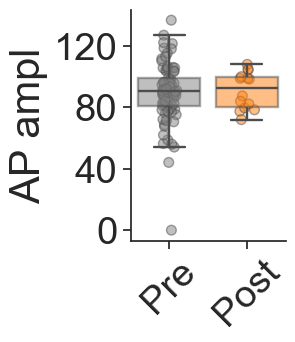

AP_halfwidth ('Pre', 'Post') 0.5464985066816404
pre_post_state
Post    3.222143
Pre     2.742533
Name: AP_halfwidth, dtype: float64


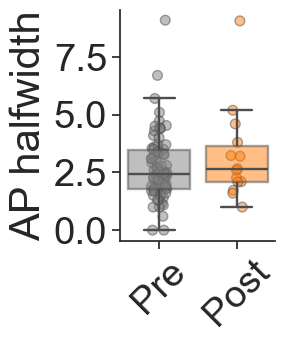

AP_time_to_peak ('Pre', 'Post') 0.5474471590998717
pre_post_state
Post    2.285000
Pre     2.515395
Name: AP_time_to_peak, dtype: float64


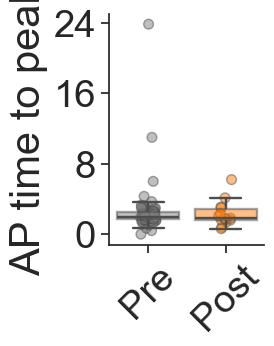

area(mV_ms) ('Pre', 'Post') 0.5257107991262155
pre_post_state
Post    287.642857
Pre     271.780263
Name: area(mV_ms), dtype: float64


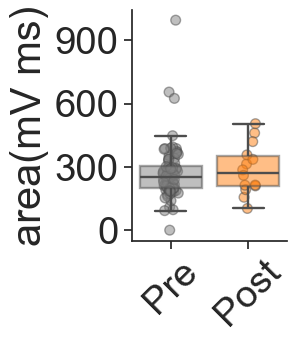

rheobase_at_-60mV_(pA) ('Pre', 'Post') 0.44825560824332966
pre_post_state
Post    24.041667
Pre     16.680556
Name: rheobase_at_-60mV_(pA), dtype: float64


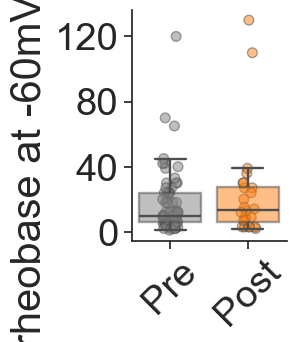

AHP_(mV) ('Pre', 'Post') 0.4590823465519721
pre_post_state
Post   -53.819286
Pre    -52.533553
Name: AHP_(mV), dtype: float64


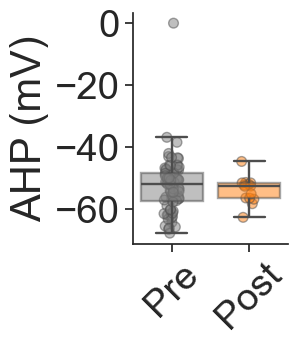

Vm ('Pre', 'Post') 0.5756446837390514
pre_post_state
Post   -48.172121
Pre    -46.452003
Name: Vm, dtype: float64


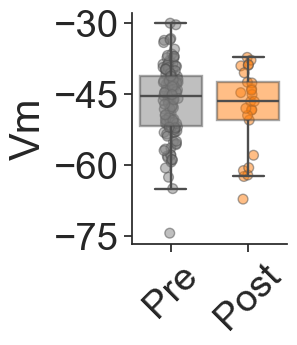

RI (MΩ) ('Pre', 'Post') 0.013647793551991269
pre_post_state
Post    744.169135
Pre     623.185777
Name: RI (MΩ), dtype: float64


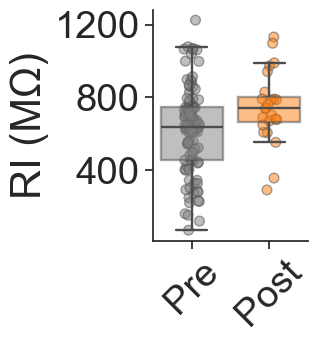

sPSC_frequency ('Pre', 'Post') 0.39395494324395697
pre_post_state
Post    2.02613
Pre     2.09123
Name: sPSC_frequency, dtype: float64


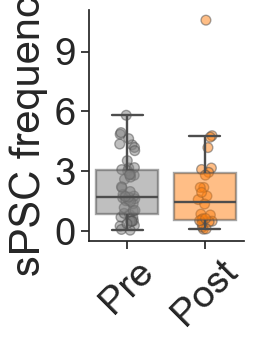

sPSC_Amplitude(pA) ('Pre', 'Post') 0.14118204125179015
pre_post_state
Post    11.695165
Pre     13.025274
Name: sPSC_Amplitude(pA), dtype: float64


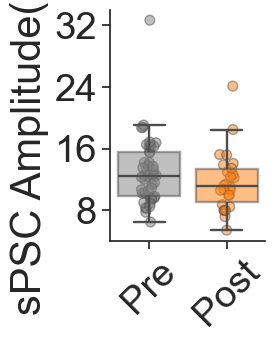

sPSCs_Rise time ('Pre', 'Post') 0.6750627879812556
pre_post_state
Post    1.142308
Pre     1.125581
Name: sPSCs_Rise time, dtype: float64


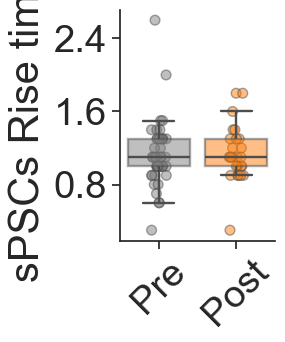

sPSCs (decay) ('Pre', 'Post') 0.8687497375928509
pre_post_state
Post     9.966788
Pre     12.018729
Name: sPSCs (decay), dtype: float64


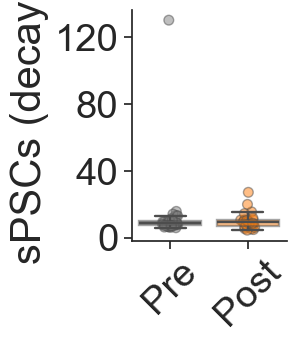

In [3]:
filter_cat = ['Pre', 'Agg+', 'Agg-']

ephys = pd.read_csv('sampled_ephys_data.csv')
ephys['pre_post_state'] = ephys['Behaviour_6hFD'].apply(lambda x: 'Pre' if x == 'Pre' else 'Post')
ephys.rename(columns = {'Input_Resistance': 'RI (MΩ)', 'Ih_at_-120mV': 'Sag (mV)'}, inplace = True)


filtered_ephys = ephys[ephys.Behaviour_6hFD.isin(filter_cat)]
agg = ephys[ephys.Behaviour_6hFD == 'Agg+']
agg_size = agg.shape[0]
no_agg = ephys[ephys.Behaviour_6hFD == 'Agg-'].sample(n = int(agg_size*0.25), random_state = 40)
sampled_ephys = pd.concat([filtered_ephys[filtered_ephys.Behaviour_6hFD == 'Pre'], agg, no_agg])


preprocess_plot(sampled_ephys,'pre_post_state', 'pan', 
                palette=['Gray', 'Tab:orange'], order = ['Pre', 'Post'],
                  plotting= True)

Cm(pF) ('Pre', 'Post') 0.5714285714285714
pre_post_state
Post    49.056072
Pre     31.119800
Name: Cm(pF), dtype: float64


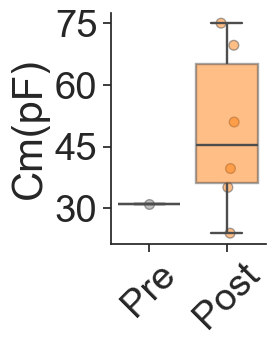

Firing_freq_(Hz)_I0 ('Pre', 'Post') 0.13692476586497737
pre_post_state
Post    0.416667
Pre     1.666667
Name: Firing_freq_(Hz)_I0, dtype: float64


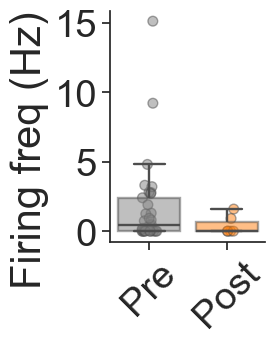

Instant_freq_(Hz) ('Pre', 'Post') 0.1476856760428134
pre_post_state
Post    0.820000
Pre     2.177576
Name: Instant_freq_(Hz), dtype: float64


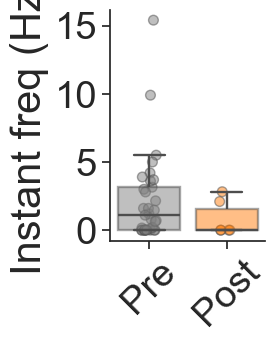

isi_(ms) ('Pre', 'Post') 1.0
pre_post_state
Post     862.000000
Pre     4610.426087
Name: isi_(ms), dtype: float64


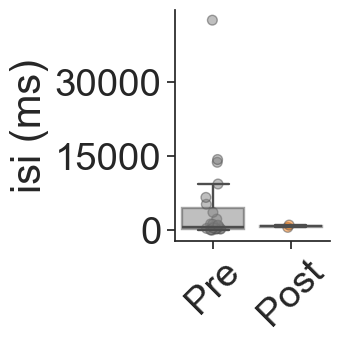

CaT ('Pre', 'Post') 0.03731359469311368
pre_post_state
Post    0.00000
Pre     7.81037
Name: CaT, dtype: float64


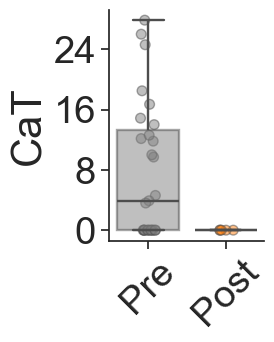

Sag (mV) ('Pre', 'Post') 0.018896038982169412
pre_post_state
Post    2.466000
Pre     9.266667
Name: Sag (mV), dtype: float64


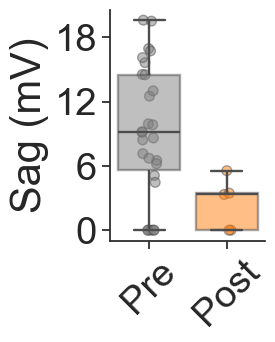

AP_ampl ('Pre', 'Post') 0.5894736842105263
pre_post_state
Post    101.700000
Pre      90.020556
Name: AP_ampl, dtype: float64


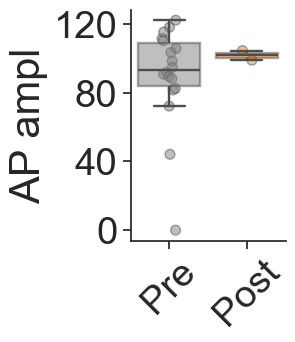

AP_halfwidth ('Pre', 'Post') 0.3604079425187944
pre_post_state
Post    1.5500
Pre     2.1875
Name: AP_halfwidth, dtype: float64


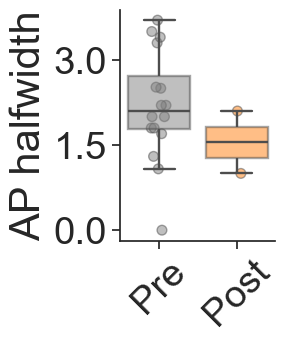

AP_time_to_peak ('Pre', 'Post') 0.05365634256335393
pre_post_state
Post    1.105000
Pre     3.732353
Name: AP_time_to_peak, dtype: float64


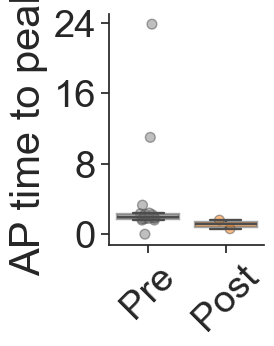

area(mV_ms) ('Pre', 'Post') 0.6549707602339181
pre_post_state
Post    208.500000
Pre     308.629412
Name: area(mV_ms), dtype: float64


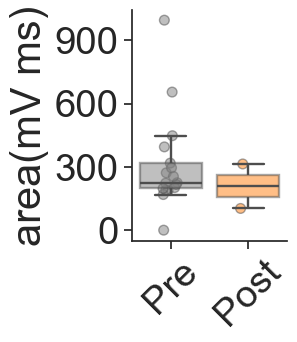

rheobase_at_-60mV_(pA) ('Pre', 'Post') 0.17208033843284476
pre_post_state
Post    20.4
Pre     17.5
Name: rheobase_at_-60mV_(pA), dtype: float64


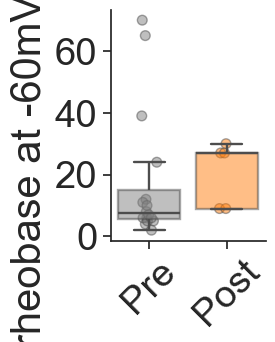

AHP_(mV) ('Pre', 'Post') 0.9473684210526315
pre_post_state
Post   -54.850000
Pre    -51.471176
Name: AHP_(mV), dtype: float64


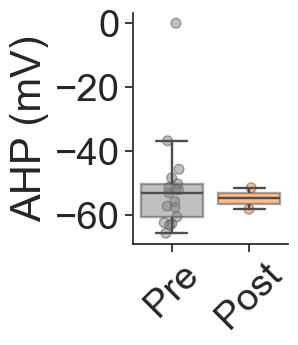

Vm ('Pre', 'Post') 0.4448467606362343
pre_post_state
Post   -50.250637
Pre    -46.635967
Name: Vm, dtype: float64


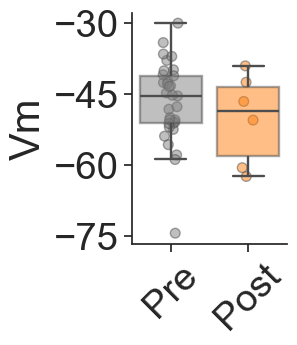

RI (MΩ) ('Pre', 'Post') 0.034850230414746546
pre_post_state
Post    757.096451
Pre     559.156051
Name: RI (MΩ), dtype: float64


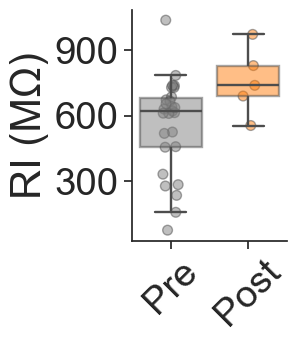

sPSC_frequency ('Pre', 'Post') 1.0
pre_post_state
Post    1.398789
Pre     1.545868
Name: sPSC_frequency, dtype: float64


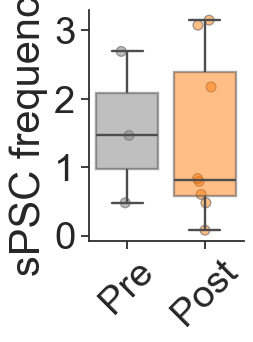

sPSC_Amplitude(pA) ('Pre', 'Post') 0.7757575757575759
pre_post_state
Post    12.747312
Pre     10.864000
Name: sPSC_Amplitude(pA), dtype: float64


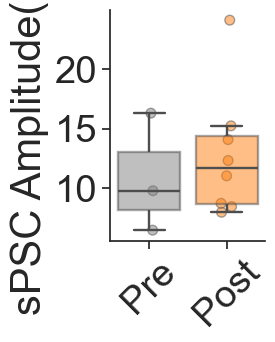

sPSCs_Rise time ('Pre', 'Post') 0.20846835079977
pre_post_state
Post    1.1375
Pre     1.0000
Name: sPSCs_Rise time, dtype: float64


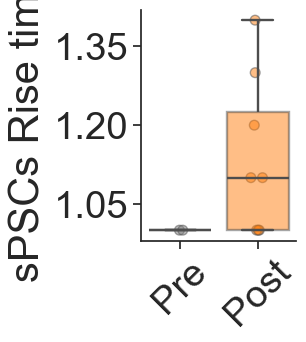

sPSCs (decay) ('Pre', 'Post') 0.17777777777777778
pre_post_state
Post    11.226375
Pre      7.550000
Name: sPSCs (decay), dtype: float64


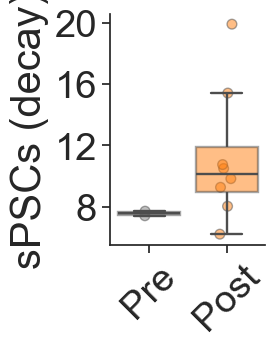

In [4]:
preprocess_plot(ephys[ephys.estrous_stage == 'D'],'pre_post_state', 'pan', 
                palette=['Gray', 'Tab:orange'], order = ['Pre', 'Post'],
                  plotting= True)

Cm(pF) ('Pre', 'Agg-') 0.6828282828282828
Behaviour_6hFD
Agg-    97.997995
Pre     37.283731
Name: Cm(pF), dtype: float64


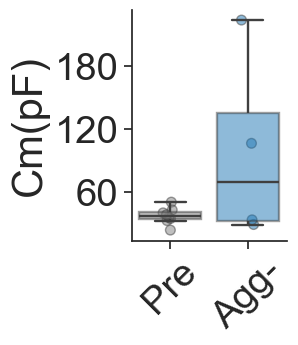

Firing_freq_(Hz)_I0 ('Pre', 'Agg-') 0.2728355421690549
Behaviour_6hFD
Agg-    2.808333
Pre     1.943214
Name: Firing_freq_(Hz)_I0, dtype: float64


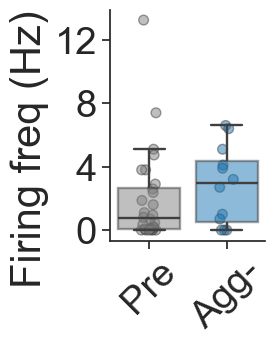

Instant_freq_(Hz) ('Pre', 'Agg-') 0.3136244229689089
Behaviour_6hFD
Agg-    3.333333
Pre     2.245357
Name: Instant_freq_(Hz), dtype: float64


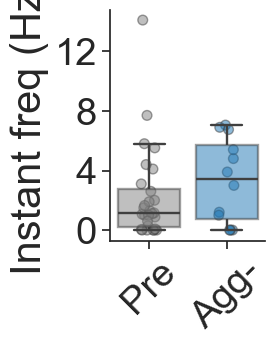

isi_(ms) ('Pre', 'Agg-') 0.029296425115705526
Behaviour_6hFD
Agg-     432.066667
Pre     4378.139130
Name: isi_(ms), dtype: float64


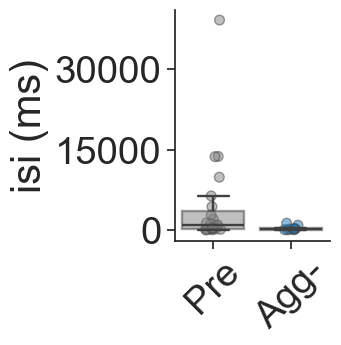

CaT ('Pre', 'Agg-') 0.26919464232932977
Behaviour_6hFD
Agg-    3.194167
Pre     2.279167
Name: CaT, dtype: float64


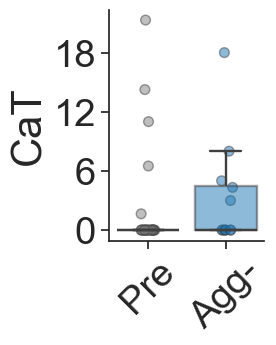

Sag (mV) ('Pre', 'Agg-') 0.6143085498461132
Behaviour_6hFD
Agg-    7.7450
Pre     7.2164
Name: Sag (mV), dtype: float64


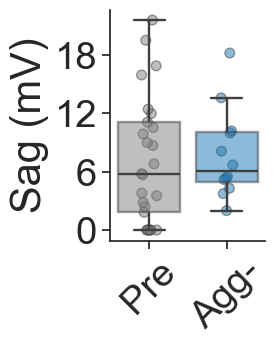

AP_ampl ('Pre', 'Agg-') 0.8014446887637376
Behaviour_6hFD
Agg-    84.003333
Pre     82.802609
Name: AP_ampl, dtype: float64


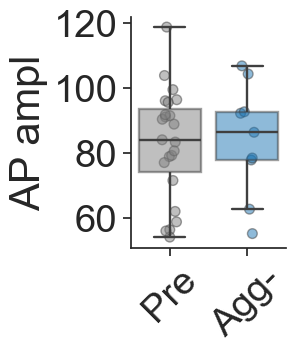

AP_halfwidth ('Pre', 'Agg-') 0.017817636532115547
Behaviour_6hFD
Agg-    2.021111
Pre     3.436087
Name: AP_halfwidth, dtype: float64


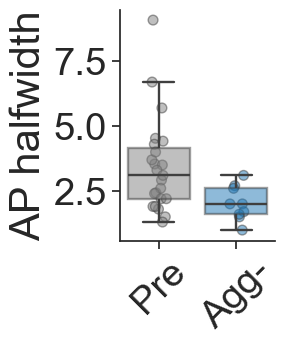

AP_time_to_peak ('Pre', 'Agg-') 0.07459670958634752
Behaviour_6hFD
Agg-    1.923333
Pre     2.521739
Name: AP_time_to_peak, dtype: float64


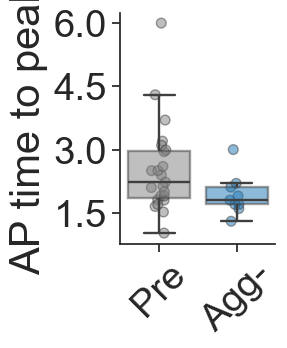

area(mV_ms) ('Pre', 'Agg-') 0.005670394938372954
Behaviour_6hFD
Agg-    184.011111
Pre     288.867826
Name: area(mV_ms), dtype: float64


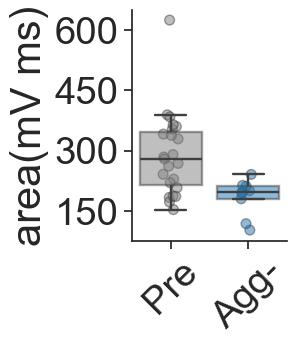

rheobase_at_-60mV_(pA) ('Pre', 'Agg-') 0.05639612371223139
Behaviour_6hFD
Agg-    28.833333
Pre     13.000000
Name: rheobase_at_-60mV_(pA), dtype: float64


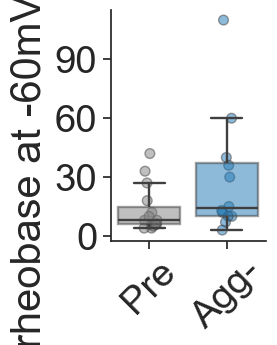

AHP_(mV) ('Pre', 'Agg-') 0.7059611308361662
Behaviour_6hFD
Agg-   -51.222222
Pre    -50.396522
Name: AHP_(mV), dtype: float64


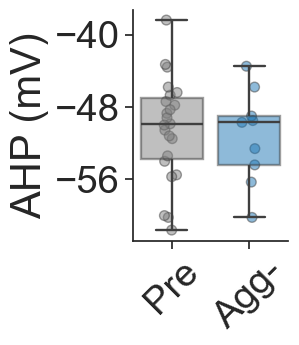

Vm ('Pre', 'Agg-') 0.6686846338999506
Behaviour_6hFD
Agg-   -47.170981
Pre    -45.606551
Name: Vm, dtype: float64


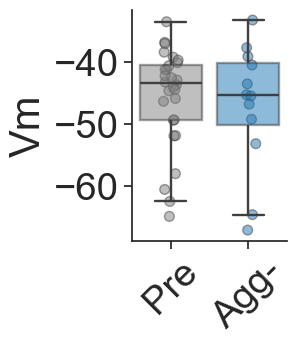

RI (MΩ) ('Pre', 'Agg-') 0.2116266930566908
Behaviour_6hFD
Agg-    544.213986
Pre     667.770236
Name: RI (MΩ), dtype: float64


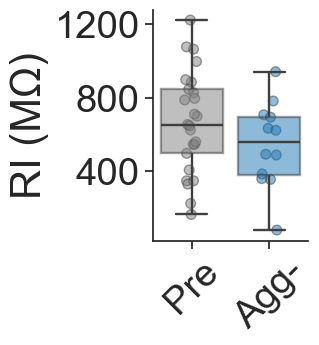

sPSC_frequency ('Pre', 'Agg-') 0.04286811881714146
Behaviour_6hFD
Agg-    1.633734
Pre     2.826389
Name: sPSC_frequency, dtype: float64


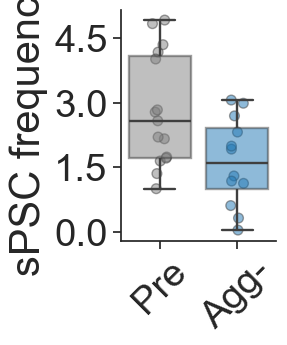

sPSC_Amplitude(pA) ('Pre', 'Agg-') 0.4206099854943849
Behaviour_6hFD
Agg-    13.841667
Pre     12.697333
Name: sPSC_Amplitude(pA), dtype: float64


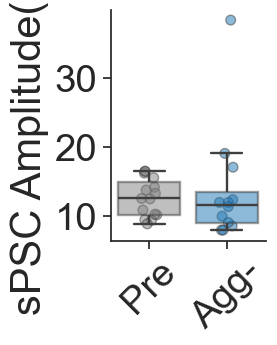

sPSCs_Rise time ('Pre', 'Agg-') 0.034314915123220234
Behaviour_6hFD
Agg-    1.233333
Pre     1.186667
Name: sPSCs_Rise time, dtype: float64


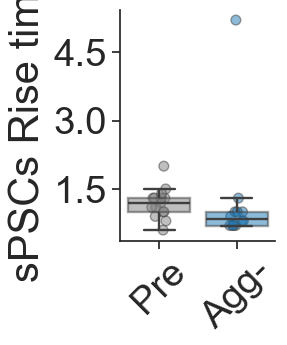

sPSCs (decay) ('Pre', 'Agg-') 0.6083530708674068
Behaviour_6hFD
Agg-     8.491667
Pre     17.485467
Name: sPSCs (decay), dtype: float64


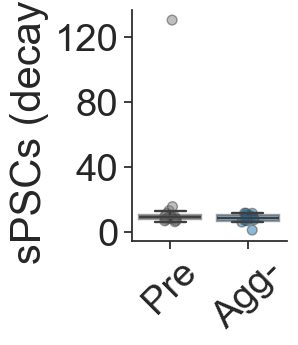

In [5]:
without_agg = ephys[ephys.Behaviour_6hFD != 'Agg+']
preprocess_plot(without_agg[without_agg.estrous_stage == 'P'],'Behaviour_6hFD', 'pan', 
                palette=['Gray', 'Tab:blue'], order = ['Pre', 'Agg-'],
                  plotting= True)

I_zero_reclassified  non_silent  silent  All
pre_post_state                              
Post                         16      11   27
Pre                          94      34  128
All                         110      45  155
SignificanceResult(statistic=0.5261121856866537, pvalue=0.16365316497983862)


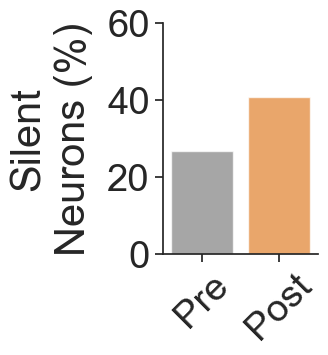

In [6]:
# % silent neurons
cols = ['silent']

cat = ['Pre', 'Agg+', 'Agg-']
sampled_ephys.loc[sampled_ephys['I_zero_reclassified'] != 'silent', 'I_zero_reclassified'] = 'non_silent'
silent_prop = proportion(sampled_ephys[sampled_ephys.Behaviour_6hFD.isin(cat)], 'pre_post_state', 'I_zero_reclassified', cols)
silent_prop['pre_post_state'] = pd.Categorical(silent_prop['pre_post_state'], ['Pre', 'Post'])
silent_prop = silent_prop.sort_values(by = ['pre_post_state'])


sns.set(rc={"figure.figsize": (2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="pre_post_state", y="silent", order=['Pre', 'Post'], palette = ['gray', 'Tab:orange'], alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('Silent\nNeurons (%)', labelpad=10)
g.set_xticklabels(('Pre', 'Post', r'Agg$^{–}$'), rotation=45)
plt.xlabel('')
plt.ylim(0,60)
plt.title('')
sns.despine(bottom=False)
plt.savefig('output_figures/silent_prop_resampled.png',dpi = 300, bbox_inches = 'tight')
# g.tick_params(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

I_zero_reclassified  non_silent  silent  All
pre_post_state                              
Post                          4       4    8
Pre                          24       9   33
All                          28      13   41
SignificanceResult(statistic=0.375, pvalue=0.23717782571516616)


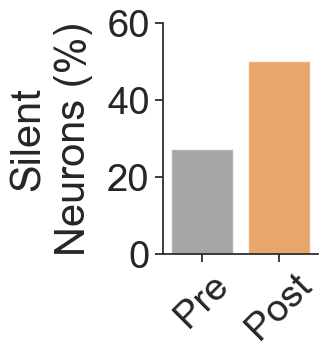

In [7]:
# % silent neurons
cols = ['silent']


estrous_balanced = ephys[ephys.estrous_stage == 'D']
estrous_balanced.loc[estrous_balanced['I_zero_reclassified'] != 'silent', 'I_zero_reclassified'] = 'non_silent'
silent_prop = proportion(estrous_balanced, 'pre_post_state', 'I_zero_reclassified', cols)
silent_prop['pre_post_state'] = pd.Categorical(silent_prop['pre_post_state'], ['Pre', 'Post'])
silent_prop = silent_prop.sort_values(by = ['pre_post_state'])


sns.set(rc={"figure.figsize": (2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="pre_post_state", y="silent", order=['Pre', 'Post'], palette = ['gray', 'Tab:orange'], alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('Silent\nNeurons (%)', labelpad=10)
g.set_xticklabels(('Pre', 'Post'), rotation=45)
plt.xlabel('')
plt.ylim(0,60)
plt.title('')
sns.despine(bottom=False)
plt.savefig('output_figures/silent_prop_estrous_controled.png',dpi = 300, bbox_inches = 'tight')


I_zero_reclassified  non_silent  silent  All
Behaviour_6hFD                              
Agg-                          9       3   12
Pre                          23       6   29
All                          32       9   41
SignificanceResult(statistic=0.782608695652174, pvalue=1.0)


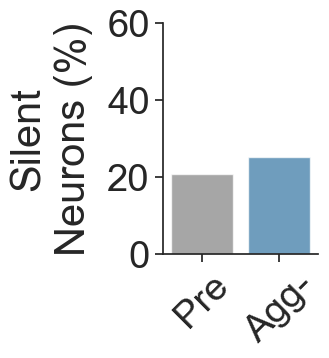

In [8]:
# % silent neurons
cols = ['silent']


estrous_balanced = without_agg[without_agg.estrous_stage == 'P']
estrous_balanced.loc[estrous_balanced['I_zero_reclassified'] != 'silent', 'I_zero_reclassified'] = 'non_silent'
silent_prop = proportion(estrous_balanced, 'Behaviour_6hFD', 'I_zero_reclassified', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], ['Pre', 'Agg-'])
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])


sns.set(rc={"figure.figsize": (2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg-'], palette = ['gray', 'Tab:blue'], alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('Silent\nNeurons (%)', labelpad=10)
g.set_xticklabels(('Pre', 'Agg-'), rotation=45)
plt.xlabel('')
plt.ylim(0,60)
plt.title('')
sns.despine(bottom=False)
plt.savefig('output_figures/silent_prop_estrous_controled.png',dpi = 300, bbox_inches = 'tight')

In [9]:
ramp_path = 'ramps_all.csv'
import os
if os.path.exists(ramp_path):
    df_state = pd.read_csv(ramp_path)

In [10]:
def process_df_state(df_state, states):
    # Rename the column
    df_state.rename(columns={'I_Injected(pA)': 'Injected'}, inplace=True)
    
    # Create and order the 'Injected' categorical column
    current_cat = np.arange(25, 175, 10)
    df_state['Injected'] = pd.Categorical(df_state['Injected'], current_cat).as_ordered()
    
    # Sort by 'Injected' and drop NaN values
    df_state.sort_values('Injected', inplace=True)
    df_state = df_state.dropna()
    
    # Create and order the 'state' categorical column
    df_state['state'] = pd.Categorical(df_state['state'], states).as_ordered()

    # Generate a DataFrame with all unique combinations of 'filename' and 'state'
    unique_combinations = df_state[['filename', 'state']].drop_duplicates()
    
    # Create a MultiIndex with all combinations of unique_combinations and current_cat
    all_combinations = unique_combinations.assign(dummy=1).merge(pd.DataFrame({'Injected': current_cat, 'dummy': 1}), on='dummy').drop('dummy', axis=1)
    
    # Merge with the original data to ensure all combinations are present
    df_state_full = all_combinations.merge(df_state, on=['filename', 'Injected', 'state'], how='left')
    # Calculate the number of spikes
    num_spike = df_state.groupby(by=['filename', 'Injected', 'state'])['Event start '].nunique().reset_index(name='num_spike')
    
    # Merge all combinations with num_spike to ensure all categories are present
    num_spike = all_combinations.merge(num_spike, on=['filename', 'Injected', 'state'], how='left').fillna({'num_spike': 0})
    
    # Get the first occurrence in each group and drop duplicates
    df_all = df_state_full.groupby(['filename', 'Injected', 'state']).first().reset_index().drop_duplicates()
    
    # Calculate the latency
    latency = df_state.groupby(['filename', 'Injected', 'state'])['Event start '].min().reset_index(name='latency_event_start')
    
    # Merge the calculated values into df_all
    df_all = pd.merge(df_all, num_spike, on=['filename', 'Injected','state'])
    df_all = pd.merge(df_all, latency, on=['filename', 'Injected','state'])
    df_all['latency'] = df_all['latency_event_start'] - df_all['Ramp_start']
    
    return df_all

states = ['Pre', 'Agg+', 'Agg-', 'NPY 10nM', 'NPY 100nM', 'NPY Antag', 'NPY1R', 'NPY2R', 'NPY-KD', 'ZD7288']
df_all = process_df_state(df_state, states)


In [11]:
sampled_ephys.rename(columns = {'experiment_day': 'filename'}, inplace = True)
sampled_ephys['filename'] = sampled_ephys['filename'].str.upper()

df_all['filename'] = df_all['filename'].str.replace('.xlsx', '').str.upper()

combined_df = df_all.merge(sampled_ephys, on = 'filename', how = 'inner')


In [12]:
test_df = df_all.merge(sampled_ephys, on = 'filename', how = 'left')
test_df = test_df[test_df['state_x'] == 'Pre']
test_df.loc[test_df['estrous_stage'] == 'P<E', 'estrous_stage'] = 'E'
print(test_df[test_df['estrous_stage'].isna()].filename.unique())
print(test_df[~test_df['estrous_stage'].isin(['P', 'E', 'M', 'D'])].filename.unique())

['S1C1 27072023' 'S2C1 24072023']
['S1C1 23112023' 'S1C1 27072023' 'S2C1 24072023']


In [13]:
print(test_df.groupby('estrous_stage')['filename'].nunique())

estrous_stage
D                    4
E                    2
M                    7
P                    7
VS to be stained     1
Name: filename, dtype: int64


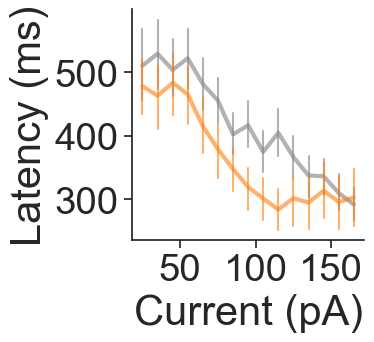

In [14]:
sns.set(font_scale=2.5) 
sns.set_style("ticks")

prop = 'latency'

fig, ax = plt.subplots(figsize = [3,3])

palette = ['gray', 'Tab:orange']
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]
combined_df['pre_post_state'] = pd.Categorical(combined_df['pre_post_state'], ['Pre', 'Post'])

sns.lineplot(data=combined_df, x="Injected", y=prop, hue = 'pre_post_state', palette=palette, err_style="bars", ci=58,  
             linewidth=3, alpha=0.6, sort=True)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Latency (ms)")
ax.set_xlabel("Current (pA)")
plt.title('')
# plt.ylim(0,20)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
sns.despine(bottom=False)
plt.savefig(f'output_figures/{prop}_resampled.png',dpi = 300, bbox_inches = 'tight')

estrous_stage  pre_post_state  Injected
D              Post            25          6
                               35          6
                               45          6
                               55          6
                               65          6
                               75          6
                               85          6
                               95          6
                               105         6
                               115         6
                               125         6
                               135         6
                               145         6
                               155         6
                               165         6
               Pre             25          4
                               35          4
                               45          4
                               55          4
                               65          4
                               75          4
               

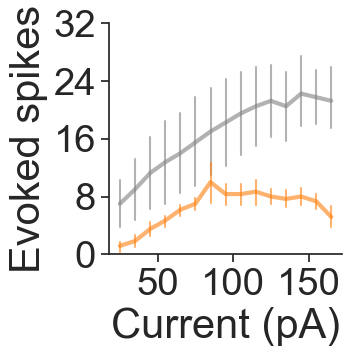

In [15]:
ephys.rename(columns = {'experiment_day': 'filename'}, inplace = True)
ephys['filename'] = ephys['filename'].str.upper()
combined_df = df_all.merge(ephys, on = 'filename', how = 'inner')
print(combined_df[combined_df.estrous_stage == 'D'].groupby(['estrous_stage','pre_post_state', 'Injected']).size())
combined_df['pre_post_state'] = pd.Categorical(combined_df['pre_post_state'], ['Pre', 'Post'])


sns.set(font_scale=2.5) 
sns.set_style("ticks")

prop = 'num_spike'

fig, ax = plt.subplots(figsize = [3,3])

palette = ['gray', 'Tab:orange']
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]

sns.lineplot(data=combined_df[combined_df.estrous_stage == 'D'], x="Injected", y=prop, hue = 'pre_post_state', palette=palette, err_style="bars", ci=58,  
             linewidth=3, alpha=0.6)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
plt.title('')
plt.ylim(0,32)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
sns.despine(bottom=False)
plt.savefig('output_figures/evoked_spikes_estrous_resampled.png',dpi = 300, bbox_inches = 'tight')

estrous_stage  pre_post_state  Injected
P              Post            25          11
                               35          11
                               45          11
                               55          11
                               65          11
                               75          11
                               85          11
                               95          11
                               105         11
                               115         11
                               125         11
                               135         11
                               145         11
                               155         11
                               165         11
               Pre             25           7
                               35           7
                               45           7
                               55           7
                               65           7
                               75       

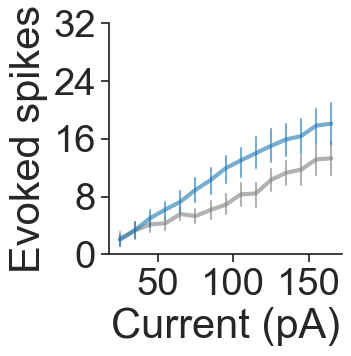

In [16]:
ephys.rename(columns = {'experiment_day': 'filename'}, inplace = True)
ephys['filename'] = ephys['filename'].str.upper()
combined_df = df_all.merge(ephys, on = 'filename', how = 'inner')
combined_df = combined_df[combined_df['Behaviour_6hFD'] != 'Agg+']
print(combined_df[combined_df.estrous_stage == 'P'].groupby(['estrous_stage','pre_post_state', 'Injected']).size())
combined_df['Behaviour_6hFD'] = pd.Categorical(combined_df['Behaviour_6hFD'], ['Pre', 'Agg-'])


sns.set(font_scale=2.5) 
sns.set_style("ticks")

prop = 'num_spike'

fig, ax = plt.subplots(figsize = [3,3])

palette = ['gray', 'Tab:blue']
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]

sns.lineplot(data=combined_df[combined_df.estrous_stage == 'P'], x="Injected", y=prop, hue = 'Behaviour_6hFD', palette=palette, err_style="bars", ci=58,  
             linewidth=3, alpha=0.6)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
plt.title('')
plt.ylim(0,32)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
sns.despine(bottom=False)
plt.savefig('output_figures/evoked_spikes_estrous_resampled.png',dpi = 300, bbox_inches = 'tight')

In [18]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
# Two-way ANOVA
model = smf.ols('latency ~  C(pre_post_state) * Injected', data=combined_df[combined_df.estrous_stage == 'P']).fit()
anova_results = sm.stats.anova_lm(model, typ=2)

print(anova_results)


                                  sum_sq     df         F    PR(>F)
C(pre_post_state)           2.947257e+04    1.0  0.742764  0.389779
Injected                    1.584765e+06   14.0  2.852790  0.000610
C(pre_post_state):Injected  1.769168e+05   14.0  0.318474  0.991256
Residual                    8.173991e+06  206.0       NaN       NaN
